# EE446 - TinyML - Assignment 2

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from pylab import rcParams
from sklearn.model_selection import train_test_split
from tensorflow.keras import datasets, layers,models
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Activation
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
from tensorflow.keras import regularizers
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score
import c_writer
from os.path import join

2026-06-09 14:27:56.089857: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Reading Data

In [2]:
# Reading the data and adding column header (feature) names
data = pd.read_csv("Network_anomaly_data.txt",sep=",",names=["duration","protocoltype","service",
"flag","srcbytes","dstbytes","land", "wrongfragment","urgent","hot","numfailedlogins","loggedin", "numcompromised",
"rootshell","suattempted","numroot","numfilecreations", "numshells","numaccessfiles","numoutboundcmds","ishostlogin",
"isguestlogin","count","srvcount","serrorrate", "srvserrorrate","rerrorrate","srvrerrorrate","samesrvrate",
"diffsrvrate", "srvdiffhostrate","dsthostcount","dsthostsrvcount","dsthostsamesrvrate", "dsthostdiffsrvrate",
"dsthostsamesrcportrate","dsthostsrvdiffhostrate","dsthostserrorrate","dsthostsrvserrorrate","dsthostrerrorrate",
"dsthostsrvrerrorrate","attack", "lastflag"])

In [3]:
data # printing the dataframe

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


## Question 1: Data Preprocessing

##### (a) Drop the 'land', 'urgent', 'numfailedlogins', 'numoutboundcmds' columns from the dataframe "data".

In [4]:
# Q1(a): Drop specified columns
data = data.drop(['land', 'urgent', 'numfailedlogins', 'numoutboundcmds'], axis=1)

##### (b) Change any label that is not named normal to attack in the {'attack'} column of the dataframe data.

In [5]:
# Q1(b): Relabel any non-normal label to 'attack'
data['attack'] = data['attack'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

In [6]:
data #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,19
3,0,tcp,http,SF,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,attack,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,20


##### (c) Use LabelEncoder() function from the sklearn.preprocessing library to convert non-numerical attributes in the {'protocoltype', 'service', 'flag', 'attack'} columns of the dataframe data to numerical values.

In [7]:
# Q1(c): Encode categorical columns to numeric values
le = LabelEncoder()
for col in ['protocoltype', 'service', 'flag', 'attack']:
    data[col] = le.fit_transform(data[col])

In [8]:
pd.DataFrame(data) #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,19
3,0,1,24,9,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1,21
4,0,1,24,9,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,1,49,5,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,0,20
125969,8,2,49,9,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,1,21
125970,0,1,54,9,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,1,18
125971,0,1,30,5,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,20


## Feature Scaling and Train/Test Split

In [9]:
# All the features apart from Attack are what we are going to use to predict the attack status of the data
# attack = 1 (normal/not an attack) and attack = 0 (attack)
X = data.drop(['attack'],axis=1).to_numpy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_normalized = scaler.fit_transform(X)

Y = data['attack'].to_numpy()
# Splitting X and y testing and training data
# we are taking 20% of the data for testing and 80% of the data for training
X_train, X_test, y_train, y_test = train_test_split(X_normalized, Y, test_size = 0.20, random_state=42)
# reshaping y test and train array
y_train = y_train.reshape(len(y_train),1)
y_test = y_test.reshape(len(y_test),1)

## Question 2: Dimensionality Reduction for Visualization

##### (a) Use TSNE from the sklearn.manifold library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

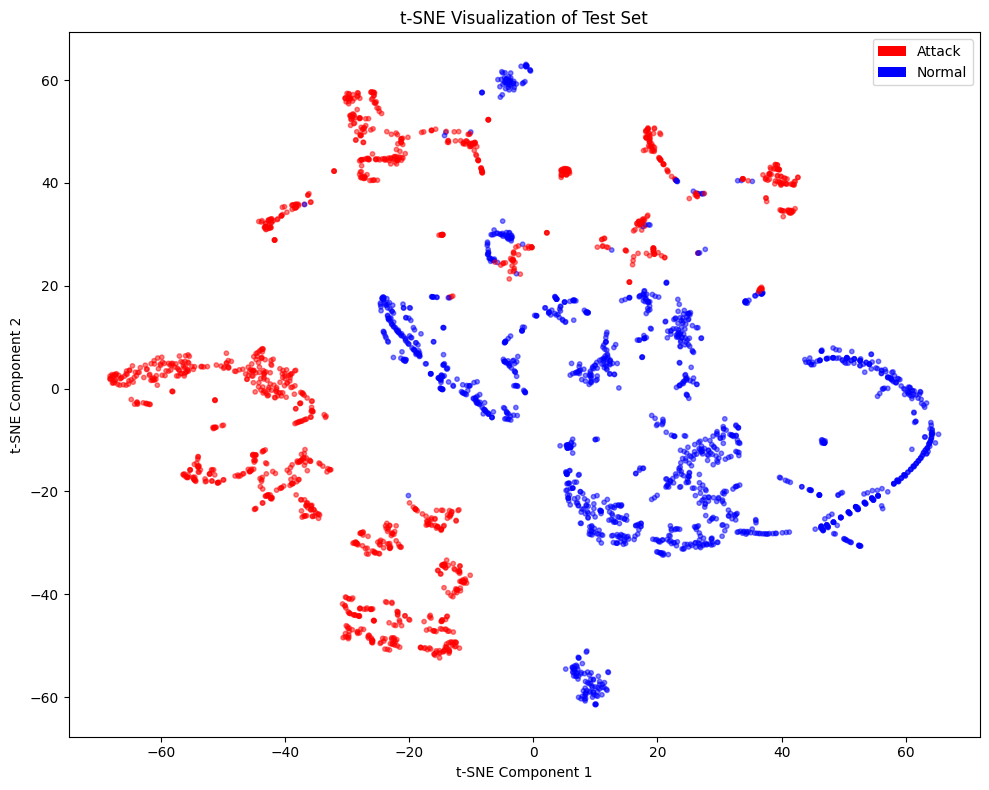

In [10]:
from sklearn.manifold import TSNE
from matplotlib.patches import Patch

# Sample 3000 points for t-SNE (computationally expensive on full test set)
np.random.seed(42)
idx = np.random.choice(len(X_test), size=3000, replace=False)
X_samp = X_test[idx]
y_samp = y_test.flatten()[idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_samp)

# attack=0 -> red, normal=1 -> blue
colors = ['blue' if y == 1 else 'red' for y in y_samp]
plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.5, s=10)
plt.title('t-SNE Visualization of Test Set')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
legend_elements = [Patch(facecolor='red', label='Attack'), Patch(facecolor='blue', label='Normal')]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

##### (b) Use PCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

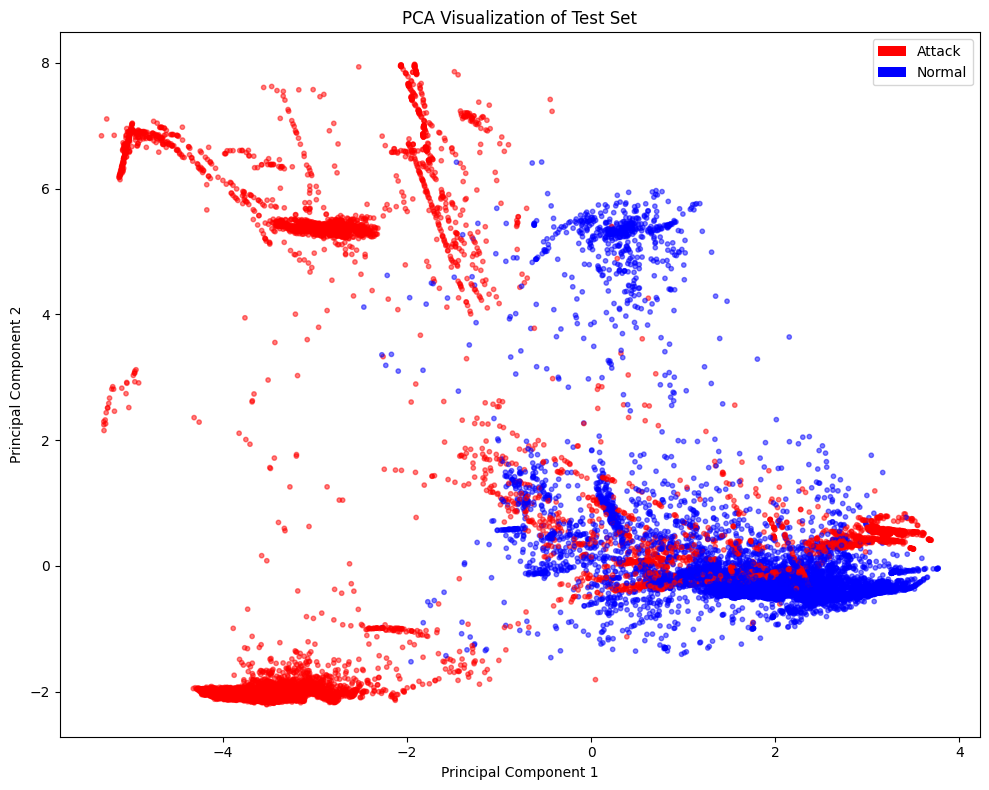

In [11]:
from sklearn.decomposition import PCA
from matplotlib.patches import Patch

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test)

y_flat = y_test.flatten()
colors = ['blue' if y == 1 else 'red' for y in y_flat]
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.5, s=10)
plt.title('PCA Visualization of Test Set')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
legend_elements = [Patch(facecolor='red', label='Attack'), Patch(facecolor='blue', label='Normal')]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

##### (c) Use KernelPCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. Use radial basis function (rbf) as the kernel. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

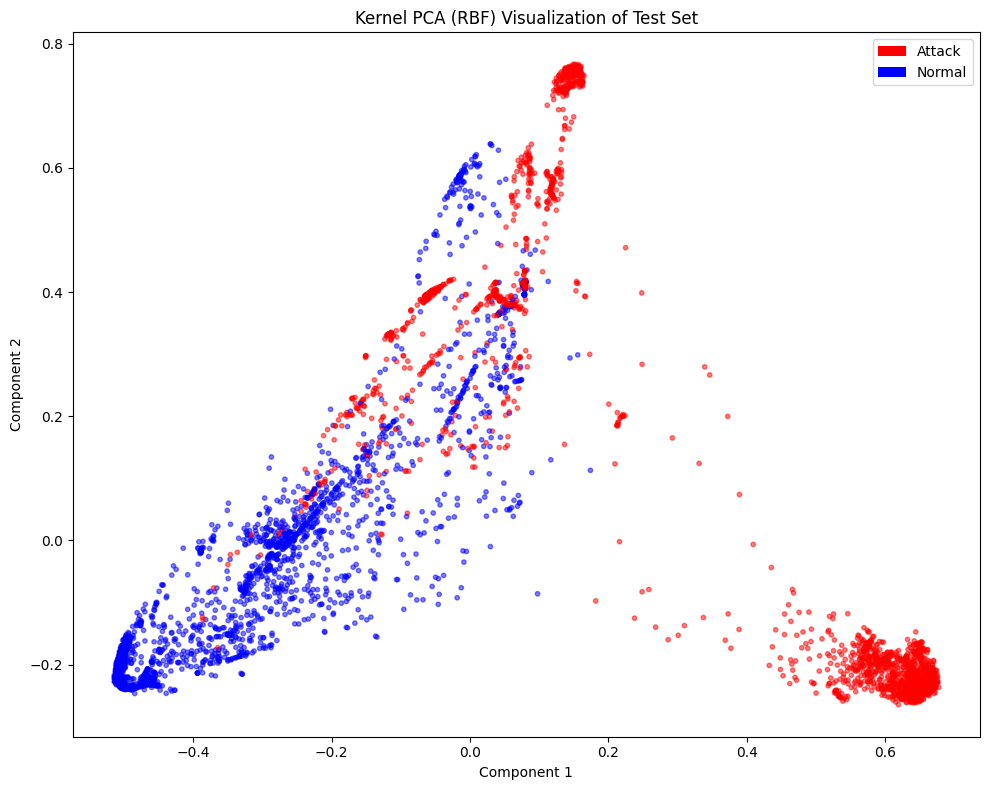

In [12]:
from sklearn.decomposition import KernelPCA
from matplotlib.patches import Patch

# Sample 5000 points for KernelPCA (O(n^3) memory for rbf kernel)
np.random.seed(42)
idx_k = np.random.choice(len(X_test), size=5000, replace=False)
X_samp_k = X_test[idx_k]
y_samp_k = y_test.flatten()[idx_k]

kpca = KernelPCA(n_components=2, kernel='rbf', random_state=42)
X_kpca = kpca.fit_transform(X_samp_k)

colors = ['blue' if y == 1 else 'red' for y in y_samp_k]
plt.figure(figsize=(10, 8))
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=colors, alpha=0.5, s=10)
plt.title('Kernel PCA (RBF) Visualization of Test Set')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
legend_elements = [Patch(facecolor='red', label='Attack'), Patch(facecolor='blue', label='Normal')]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

## Question 3: Implementing a DNN on the dataset

##### (a) Implement a deep neural network (DNN) on the Network Anomaly Dataset. Ensure to include two neurons and softmax activation in the output layer of your DNN.

In [13]:
# Define the DNN model
base_model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(2, activation='softmax')
])
base_model.summary()

Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 dense (Dense)               (None, 16)                624       


 dense_1 (Dense)             (None, 8)                 136       


 dense_2 (Dense)             (None, 2)                 18        


Total params: 778 (3.04 KB)


Trainable params: 778 (3.04 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


##### (b) Compile and train your DNN model on the training set (X_train). Denote the trained model as base_model.

In [14]:
# Q3(b): Compile and train the DNN
base_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = base_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20


  1/355 [..............................] - ETA: 2:47 - loss: 0.7363 - accuracy: 0.5234

 44/355 [==>...........................] - ETA: 0s - loss: 0.5881 - accuracy: 0.7753  

 89/355 [======>.......................] - ETA: 0s - loss: 0.4681 - accuracy: 0.8467

137/355 [==========>...................] - ETA: 0s - loss: 0.3720 - accuracy: 0.8806

...

184/355 [==============>...............] - ETA: 0s - loss: 0.0052 - accuracy: 0.9981

227/355 [==================>...........] - ETA: 0s - loss: 0.0052 - accuracy: 0.9982

276/355 [======================>.......] - ETA: 0s - loss: 0.0050 - accuracy: 0.9983

318/355 [=========================>....] - ETA: 0s - loss: 0.0050 - accuracy: 0.9983

355/355 [==============================] - 0s 1ms/step - loss: 0.0051 - accuracy: 0.9983 - val_loss: 0.0058 - val_accuracy: 0.9984


##### (c) Evaluate the base_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

  1/788 [..............................] - ETA: 56s

 46/788 [>.............................] - ETA: 0s 

108/788 [===>..........................] - ETA: 0s

171/788 [=====>........................] - ETA: 0s

232/788 [=======>......................] - ETA: 0s

...

639/788 [=======================>......] - ETA: 0s

703/788 [=========================>....] - ETA: 0s

761/788 [===========================>..] - ETA: 0s

788/788 [==============================] - 1s 867us/step


Classification Report - Base Model:
              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     11773
      normal       1.00      1.00      1.00     13422

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

Confusion Matrix - Base Model:
[[11748    25]
 [   35 13387]]


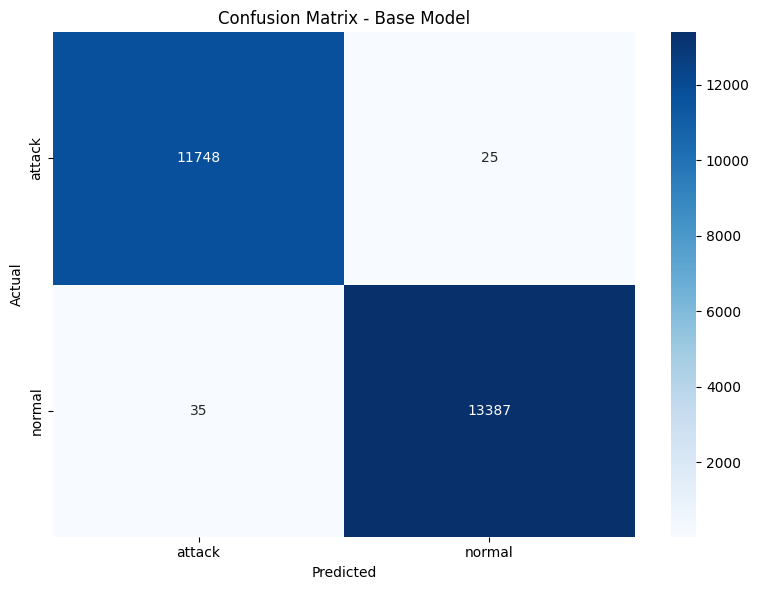

In [15]:
# Q3(c): Evaluate base_model on test set
y_pred_probs = base_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

print('Classification Report - Base Model:')
print(classification_report(y_true, y_pred, target_names=['attack', 'normal']))

cm = confusion_matrix(y_true, y_pred)
print('Confusion Matrix - Base Model:')
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['attack', 'normal'], yticklabels=['attack', 'normal'])
plt.title('Confusion Matrix - Base Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [16]:
# Save the original Keras model to HDF5 file
base_model.save('original_model.h5')

## Question 4: Implementing Quantized Model

##### (a) Implement Dynamic Range Quantization on the base_model. Designate the resulting quantized ML model as tflite_quant_model.

In [17]:
# Load the trained model
base_model = tf.keras.models.load_model('original_model.h5')

# Q4(a): Dynamic Range Quantization
converter = tf.lite.TFLiteConverter.from_keras_model(base_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()

INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp67sxxfbi/assets


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp67sxxfbi/assets


2026-06-09 14:28:21.184632: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-06-09 14:28:21.184650: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.


2026-06-09 14:28:21.185077: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp67sxxfbi
2026-06-09 14:28:21.186239: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-06-09 14:28:21.186251: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp67sxxfbi
2026-06-09 14:28:21.189137: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-06-09 14:28:21.190369: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-06-09 14:28:21.242500: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp67sxxfbi
2026-06-09 14:28:21.258284: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 

In [18]:
import os

# Save the quantized model
with open('quantized_model.tflite', 'wb') as f:
    f.write(tflite_quant_model)

# Get the file sizes
original_model_size = os.path.getsize('original_model.h5')
quantized_model_size = os.path.getsize('quantized_model.tflite')

# Print the model sizes
print(f"Original model size: {original_model_size / 1024:.2f} KB")
print(f"Quantized model size: {quantized_model_size / 1024:.2f} KB")

Original model size: 38.59 KB
Quantized model size: 5.10 KB


##### (b) Evaluate the tflite_quant_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

Classification Report - Quantized Model:
              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     11773
      normal       1.00      1.00      1.00     13422

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

Confusion Matrix - Quantized Model:
[[11748    25]
 [   35 13387]]


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


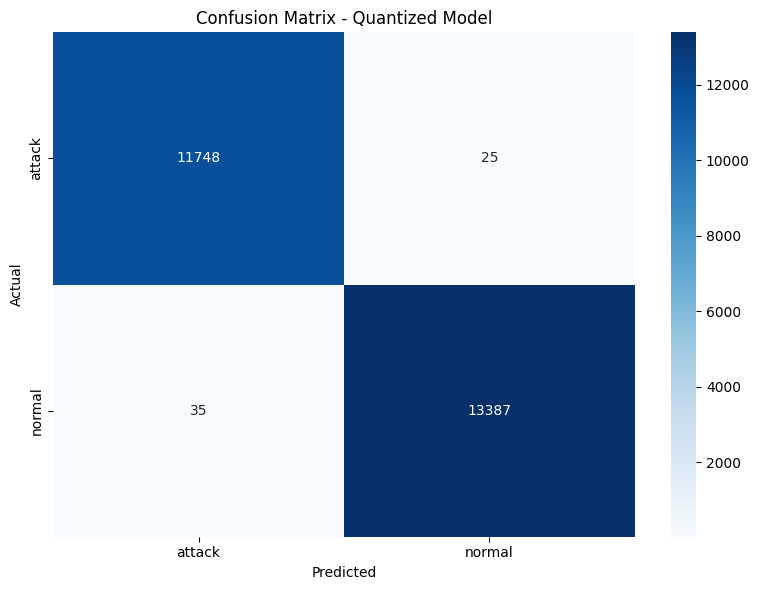

In [19]:
# Q4(b): Evaluate tflite_quant_model on test set
interpreter = tf.lite.Interpreter(model_content=tflite_quant_model)

# Resize input to run full test set in one call
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
interpreter.resize_tensor_input(input_details[0]['index'], [len(X_test), X_test.shape[1]])
interpreter.allocate_tensors()

interpreter.set_tensor(input_details[0]['index'], X_test.astype(np.float32))
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
y_pred_quant = np.argmax(output_data, axis=1)
y_true = y_test.flatten()

print('Classification Report - Quantized Model:')
print(classification_report(y_true, y_pred_quant, target_names=['attack', 'normal']))

cm_quant = confusion_matrix(y_true, y_pred_quant)
print('Confusion Matrix - Quantized Model:')
print(cm_quant)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_quant, annot=True, fmt='d', cmap='Blues',
            xticklabels=['attack', 'normal'], yticklabels=['attack', 'normal'])
plt.title('Confusion Matrix - Quantized Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Converting tflite_model to C and create the header file

In [20]:
# c_writer is a py file in the same folder and has been imported at the beginning of the notebook
# Reference : https://github.com/ShawnHymel/tinyml-example-anomaly-detection/blob/master/utils/c_writer.py
# We use #04x to pad the output to 2 digits with a 0x prefix
hex_array = [format(val, '#04x') for val in tflite_quant_model]
# Calling function to convert an array into a C string (requires Numpy)
# create_array(np_array, var_type, var_name, line_limit=80, indent=4)
c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', "network_model")
# Calling Function to create a header file with given C code as a string
header_str = c_writer.create_header(c_model, "network_model")

In [21]:
#Writing to the header file
with open('network_model.h', 'w') as file:
    file.write(header_str)

## Generating Samples for Inference on Arduino

In [22]:
# Q5(c): First 5 test samples for Arduino
Xtest = X_test[0:5,:]
print(c_writer.create_array(Xtest,'float','X_test'))

const unsigned int X_test_dim1 = 5;
const unsigned int X_test_dim2 = 38;

const float X_test[5][38] = {
    -0.11024922321249885, 2.219311849644404, -1.1761894520278895, 
    0.7511112872365361, -0.0077561081831758055, -0.004918644383724874, 
    -0.08948642202040107, -0.09507567152556495, -0.8092618187059747, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    -0.7170454919159579, -0.32680812408381416, -0.6372092679572258, 
    -0.6319290328885425, -0.37436223991967527, -0.37443160310530493, 
    0.7712831058493207, -0.349683030873482, 2.5119489320685644, 
    -1.1607075618930458, 0.49996246054886545, 1.0664013456654926, 
    -0.43907816809041417, 2.756092007079775, -0.20026454391970344, 
    -0.6395319051152512, -0.6248707997445304, -0.38763462350750655, 
    -0.3763870260680415, 0.6528228780141483, -0.1102492232124

In [23]:
ytest = y_test[0:5]
print(c_writer.create_array(ytest,'uint8_t','y_test'))

const unsigned int y_test_dim1 = 5;
const unsigned int y_test_dim2 = 1;

const uint8_t y_test[5][1] = {
    1, 0, 0, 0, 0
};



In [24]:
# Q5(d): Next 10 test samples for Arduino (excluding first 5)
Xtest_d = X_test[5:15,:]
print(c_writer.create_array(Xtest_d,'float','X_test_d'))

const unsigned int X_test_d_dim1 = 10;
const unsigned int X_test_d_dim2 = 38;

const float X_test_d[10][38] = {
    -0.11024922321249885, -0.12470615670462065, -0.44208308523109213, 
    0.7511112872365361, -0.007706877375215699, -0.0037565688369884287, 
    -0.08948642202040107, -0.09507567152556495, 1.2356940323701657, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    -0.5598514445843843, -0.10653031654754139, -0.6372092679572258, 
    -0.6319290328885425, -0.37436223991967527, -0.37443160310530493, 
    0.7712831058493207, -0.349683030873482, -0.37455970440553465, 
    0.7343425609306344, 1.2587542737799418, 1.0664013456654926, 
    -0.43907816809041417, -0.4801968475158174, -0.28910340026287856, 
    -0.6395319051152512, -0.6248707997445304, -0.38763462350750655, 
    -0.3763870260680415, 0.6528228780141483, -0.

In [25]:
ytest_d = y_test[5:15]
print(c_writer.create_array(ytest_d,'uint8_t','y_test_d'))

const unsigned int y_test_d_dim1 = 10;
const unsigned int y_test_d_dim2 = 1;

const uint8_t y_test_d[10][1] = {
    1, 0, 0, 0, 1, 0, 1, 0, 1, 1
};

